# Módulo 3 — Valoración de opciones europeas por Monte Carlo

**Proyecto:** Métodos de Monte Carlo en Finanzas Cuantitativas
**Autor:** Jorge Rodríguez Lázaro
**Última actualización:** 2026-09-23

---

## Objetivo del módulo

Este es el módulo donde el proyecto pasa de *simular* a *valorar*. Tenemos un modelo de precios (el GBM del Módulo 2); ahora lo usamos para responder la pregunta central de las finanzas cuantitativas: **¿cuánto vale hoy un contrato cuyo pago depende del precio futuro de un activo?**

El caso que resolvemos es la **opción europea** (call y put). Lo haremos por dos caminos independientes que deben coincidir:

1. **Monte Carlo:** simular miles de precios futuros bajo la medida neutral al riesgo y promediar el pago descontado.
2. **Black–Scholes:** la fórmula cerrada, que derivaremos y que sirve de patrón de oro para validar el Monte Carlo.

Que ambos caminos den el mismo número —dentro del error estadístico— es la validación de que entendemos lo que hacemos, y es también el "wow result" cuantitativo del proyecto: un método numérico genérico reproduciendo una fórmula analítica célebre.

## Estructura

| Sección | Tema | Idea clave |
|---------|------|------------|
| 1 | La opción y la valoración neutral al riesgo | Por qué el precio es $e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\text{pago}]$ y por qué desaparece $\mu$. |
| 2 | Valoración por Monte Carlo | Simular, promediar, descontar — con error estándar e intervalo de confianza. |
| 3 | Black–Scholes: la fórmula cerrada | Derivación desde la esperanza neutral al riesgo; paridad put-call. |
| 4 | Monte Carlo vs. Black–Scholes | Convergencia $1/\sqrt{N}$ y validación cruzada. |

## Referencias

- Hull, J. C. (2018). *Options, Futures and Other Derivatives*, caps. 13–15.
- Shreve, S. E. (2004). *Stochastic Calculus for Finance II*, caps. 4–5.
- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, caps. 1 y 3.
- Black, F. & Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities*. J. Political Economy.

> **Nota sobre el código.** Las funciones que aquí se derivan e implementan paso a paso (`simular_gbm`, `precio_mc`, `black_scholes`, `estimar_parametros`, …) viven además, en su versión canónica y con *type hints*, en el paquete `src/mcquant/`, cubiertas por la suite de tests de `tests/`. El notebook es la exposición; el paquete, la librería reutilizable. Se pueden importar con `from mcquant import ...`.

---

# Sección 1 — La opción y la valoración neutral al riesgo

## 1.1 Qué es una opción europea

Una **opción de compra europea** (*call*) sobre un activo es un contrato que da a su poseedor el **derecho, no la obligación**, de comprar el activo en una fecha futura fija $T$ (el *vencimiento*) a un precio pactado hoy $K$ (el *strike* o precio de ejercicio).

En el vencimiento, el poseedor actúa racionalmente:

- Si $S_T > K$: ejerce, compra a $K$ lo que vale $S_T$, y gana $S_T - K$.
- Si $S_T \le K$: no ejerce (compraría más barato en el mercado), y gana $0$.

El pago (*payoff*) de la call en $T$ es por tanto:

$$
\text{payoff}_{\text{call}} = \max(S_T - K,\; 0) = (S_T - K)^+
$$

La **opción de venta** (*put*) es simétrica: derecho a vender a $K$, con pago $(K - S_T)^+$. Son "europeas" porque solo pueden ejercerse en $T$ (las "americanas", que se pueden ejercer en cualquier momento hasta $T$, son harina de otro costal y quedan fuera de este módulo).

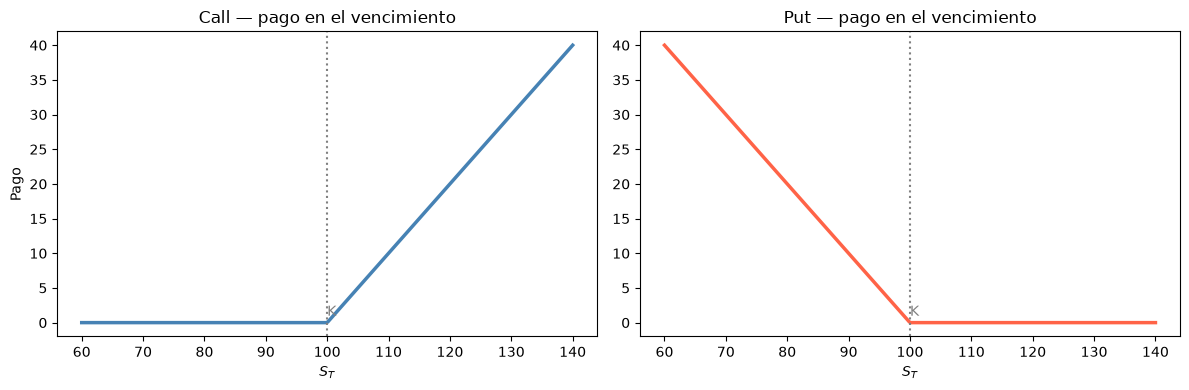

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(seed=42)

# Diagrama de pagos en el vencimiento
K = 100
S_T = np.linspace(60, 140, 400)
payoff_call = np.maximum(S_T - K, 0)
payoff_put  = np.maximum(K - S_T, 0)

fig, (axc, axp) = plt.subplots(1, 2, figsize=(12, 4))
axc.plot(S_T, payoff_call, color='steelblue', linewidth=2.5)
axc.axvline(K, color='gray', linestyle=':'); axc.set_title('Call — pago en el vencimiento')
axc.set_xlabel('$S_T$'); axc.set_ylabel('Pago'); axc.annotate('K', (K, 1), color='gray')
axp.plot(S_T, payoff_put, color='tomato', linewidth=2.5)
axp.axvline(K, color='gray', linestyle=':'); axp.set_title('Put — pago en el vencimiento')
axp.set_xlabel('$S_T$'); axp.annotate('K', (K, 1), color='gray')
for ax in (axc, axp): ax.set_ylim(-2, 42)
plt.tight_layout(); plt.show()

## 1.2 El problema de la valoración

El pago ocurre en el futuro y es **incierto**: depende de $S_T$, que no conocemos hoy. La pregunta es qué precio $V_0$ debe tener hoy este contrato.

El primer instinto —"calcular el pago esperado y descontarlo"— tropieza inmediatamente:

$$
V_0 \overset{?}{=} e^{-rT}\, \mathbb{E}[(S_T - K)^+]
$$

¿Descontar a qué tasa? ¿Y bajo qué distribución de $S_T$, es decir, con qué drift $\mu$? Aquí chocamos de frente con el resultado del Módulo 2 (§3.3): **$\mu$ es prácticamente inestimable**. Si el precio de la opción dependiera del drift real del activo, sería tan incierto como el propio drift, y dos analistas con estimaciones distintas de $\mu$ darían precios distintos. Eso no puede ser: las opciones se compran y venden a un precio único en el mercado.

La resolución de esta paradoja es una de las ideas más elegantes de las finanzas: la **valoración neutral al riesgo**.

## 1.3 Valoración neutral al riesgo: por qué desaparece $\mu$

La clave es que una opción **no se valora en el vacío**: existe el activo subyacente, que se puede comprar y vender. Y eso permite *replicar* el pago de la opción con una cartera de activo + bono, ajustada dinámicamente. Por ausencia de arbitraje, **el precio de la opción debe ser igual al coste de esa cartera replicante** — si no, habría beneficio sin riesgo.

El fenómeno crucial se ve ya en un modelo de **un solo paso** (binomial). Supongamos que hoy el activo vale $S_0$ y en $T$ solo puede tomar dos valores: $S_0 u$ (sube) o $S_0 d$ (baja), con $d < e^{rT} < u$. La opción paga $f_u$ o $f_d$ respectivamente. Buscamos una cartera de $\Delta$ acciones y $B$ euros en bono que replique el pago:

$$
\Delta S_0 u + B e^{rT} = f_u, \qquad \Delta S_0 d + B e^{rT} = f_d
$$

Resolviendo el sistema y calculando su coste hoy $V_0 = \Delta S_0 + B$, se llega tras un poco de álgebra a:

$$
V_0 = e^{-rT}\big[\, q\, f_u + (1-q)\, f_d \,\big], \qquad q = \frac{e^{rT} - d}{u - d}
$$

Obsérvese lo que **no** aparece: la probabilidad real de que el activo suba. El precio no depende de ella en absoluto — y por tanto no depende de $\mu$. La cantidad $q$ **no es** la probabilidad real de subida; es una probabilidad *sintética* bajo la cual el precio esperado del activo crece exactamente a la tasa libre de riesgo:

$$
\mathbb{E}^{\mathbb{Q}}[S_T] = q\, S_0 u + (1-q)\, S_0 d = S_0 e^{rT}
$$

Esta es la **medida neutral al riesgo** $\mathbb{Q}$: el mundo ficticio en el que todos los activos rinden la tasa libre de riesgo $r$.

En tiempo continuo, el resultado análogo es el **teorema fundamental de la valoración de activos** (Shreve, cap. 5): existe una única medida neutral al riesgo $\mathbb{Q}$ bajo la cual el precio descontado del activo es una martingala, y el precio de cualquier derivado es el valor esperado descontado de su pago bajo $\mathbb{Q}$:

$$
\boxed{V_0 = e^{-rT}\, \mathbb{E}^{\mathbb{Q}}\!\big[\text{payoff}(S_T)\big]}
$$

Bajo $\mathbb{Q}$, el activo sigue un GBM idéntico al del Módulo 2 **pero con el drift $\mu$ sustituido por $r$**:

$$
dS_t = r\, S_t\, dt + \sigma\, S_t\, dW_t^{\mathbb{Q}}
\qquad\Longrightarrow\qquad
S_T = S_0\, e^{\left(r - \frac{\sigma^2}{2}\right)T + \sigma \sqrt{T}\, Z}, \quad Z \sim \mathcal{N}(0,1)
$$

Esto es exactamente la respuesta al problema del Módulo 2: **no necesitamos estimar el drift inestimable $\mu$**, porque la valoración de derivados no lo usa. Solo necesitamos $r$ (observable en el mercado de bonos) y $\sigma$ (que sí sabíamos estimar bien). El drift real gobierna cuánto *esperas ganar* teniendo el activo, pero no cuánto *cuesta* un derivado sobre él — dos preguntas distintas que es fácil confundir.

Con esta fórmula, la estrategia de Monte Carlo es inmediata y es lo que implementamos en la Sección 2: simular muchos $S_T$ bajo $\mathbb{Q}$, calcular el pago de cada uno, promediar y descontar.

---

# Sección 2 — Valoración por Monte Carlo

## 2.1 El algoritmo

La fórmula $V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\text{payoff}]$ es una esperanza, y estimar esperanzas por promedios muestrales es precisamente lo que hace Monte Carlo (Módulo 1). El algoritmo tiene cuatro pasos:

1. Simular $N$ valores del precio final bajo $\mathbb{Q}$: $\;S_T^{(i)} = S_0\, e^{(r - \sigma^2/2)T + \sigma\sqrt{T}\, Z_i}$, con $Z_i \sim \mathcal{N}(0,1)$.
2. Calcular el pago de cada uno: $\;g_i = (S_T^{(i)} - K)^+$ para la call.
3. Descontar: $\;h_i = e^{-rT} g_i$.
4. Promediar: $\;\hat{V}_0 = \frac{1}{N}\sum_{i=1}^{N} h_i$.

No necesitamos simular *trayectorias* completas: el pago europeo solo depende de $S_T$, así que muestreamos directamente la lognormal en $T$ (más rápido y sin error de discretización). Esto es el "esquema exacto" del Módulo 2 aplicado a un único instante.

In [2]:
def precio_mc(S0, K, r, sigma, T, N, rng, tipo='call'):
    """Precio Monte Carlo de una opción europea, con su error estándar.

    Devuelve (precio, error_estandar). El pago solo depende de S_T, así que
    muestreamos la lognormal neutral al riesgo directamente.
    """
    Z   = rng.standard_normal(N)
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    if tipo == 'call':
        payoff = np.maximum(S_T - K, 0.0)
    else:
        payoff = np.maximum(K - S_T, 0.0)
    descontado = np.exp(-r * T) * payoff
    precio = descontado.mean()
    # Error estándar del estimador Monte Carlo: SE = s / sqrt(N)  (Módulo 1)
    se = descontado.std(ddof=1) / np.sqrt(N)
    return precio, se

## 2.2 Un primer precio, con su barra de error

Usamos el ejemplo canónico: activo a $S_0 = 100$, strike $K = 100$ (opción *at-the-money*), tasa libre de riesgo $r = 5\%$, volatilidad $\sigma = 20\%$, vencimiento $T = 1$ año.

Un precio Monte Carlo sin su error estándar es un número sin sentido (Módulo 2, §3.3). El estimador es un promedio de $N$ variables i.i.d., así que por el TCL (Módulo 1) su error estándar es $s/\sqrt{N}$ y el intervalo de confianza al 95% es $\hat V_0 \pm 1.96\,\mathrm{SE}$.

In [3]:
S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.20, 1.0
N = 1_000_000

for tipo in ('call', 'put'):
    precio, se = precio_mc(S0, K, r, sigma, T, N, rng, tipo)
    ic_bajo, ic_alto = precio - 1.96 * se, precio + 1.96 * se
    print(f"{tipo.upper():>4}:  precio = {precio:.4f}   SE = {se:.4f}   "
          f"IC 95% = [{ic_bajo:.4f}, {ic_alto:.4f}]")

CALL:  precio = 10.4532   SE = 0.0147   IC 95% = [10.4243, 10.4821]
 PUT:  precio = 5.5632   SE = 0.0086   IC 95% = [5.5462, 5.5801]


## 2.3 La convergencia $1/\sqrt{N}$

El error de Monte Carlo decrece como $1/\sqrt{N}$ — la lección central del Módulo 1, aquí en su aplicación financiera. Esto tiene una consecuencia práctica dura: para ganar **un decimal** de precisión (dividir el error por 10) hay que multiplicar el número de simulaciones **por 100**. Lo comprobamos midiendo el error real contra el precio de Black–Scholes (que obtendremos en la Sección 3) a medida que crece $N$.

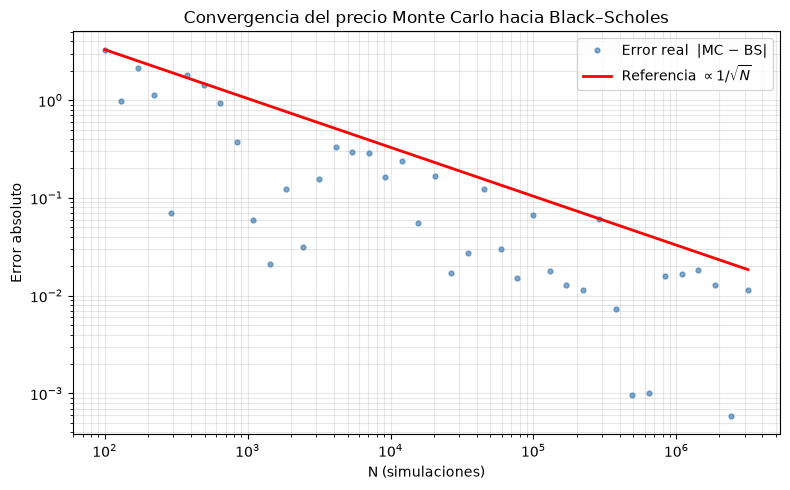

Precio Black–Scholes de referencia: 10.4506


In [4]:
# Precio de referencia Black-Scholes (se deriva en la Sección 3; lo adelantamos aquí)
def precio_bs(S0, K, r, sigma, T, tipo='call'):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if tipo == 'call':
        return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

bs_ref = precio_bs(S0, K, r, sigma, T, 'call')

Ns      = np.unique(np.logspace(2, 6.5, 40).astype(int))
errores = np.array([abs(precio_mc(S0, K, r, sigma, T, n, rng, 'call')[0] - bs_ref) for n in Ns])

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(Ns, errores, '.', color='steelblue', markersize=7, alpha=0.7, label='Error real  |MC − BS|')
ax.loglog(Ns, errores[0] * np.sqrt(Ns[0] / Ns), 'r-', linewidth=2, label=r'Referencia $\propto 1/\sqrt{N}$')
ax.set_xlabel('N (simulaciones)'); ax.set_ylabel('Error absoluto')
ax.set_title('Convergencia del precio Monte Carlo hacia Black–Scholes')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Precio Black–Scholes de referencia: {bs_ref:.4f}")

---

# Sección 3 — Black–Scholes: la fórmula cerrada

Para el GBM y el pago europeo, la esperanza neutral al riesgo se puede calcular **a mano**, en forma cerrada. El resultado es la célebre fórmula de Black–Scholes (1973). Tenerla nos da un patrón de oro exacto contra el que medir el Monte Carlo.

## 3.1 De la EDP a la esperanza: dos caminos al mismo precio

Históricamente, Black y Scholes llegaron a su fórmula por un argumento de **cobertura dinámica** (*delta-hedging*): una cartera que combina la opción con $-\partial V/\partial S$ acciones es instantáneamente libre de riesgo, y por no-arbitraje debe rendir $r$. Eso conduce a la **ecuación en derivadas parciales de Black–Scholes**:

$$
\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + r S \frac{\partial V}{\partial S} - r V = 0
$$

con la condición final $V(S, T) = \text{payoff}(S)$. El **teorema de Feynman–Kac** establece el puente entre esta EDP y la esperanza neutral al riesgo de la Sección 1: la solución de la EDP es exactamente $V_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{payoff}]$. Son dos formulaciones del mismo objeto. Aquí seguimos el camino de la esperanza, porque conecta directamente con la lognormal del Módulo 2 y no requiere resolver una EDP.

## 3.2 Derivación de la fórmula de la call

Partimos de la esperanza neutral al riesgo, con $S_T = S_0\, e^{(r - \sigma^2/2)T + \sigma\sqrt{T} Z}$ y $Z \sim \mathcal{N}(0,1)$:

$$
C = e^{-rT}\, \mathbb{E}^{\mathbb{Q}}\big[(S_T - K)^+\big]
= e^{-rT}\, \mathbb{E}\big[(S_T - K)\, \mathbf{1}_{\{S_T > K\}}\big]
$$

**Cuándo se ejerce.** La condición $S_T > K$ se traduce en una condición sobre $Z$:

$$
S_T > K \;\Longleftrightarrow\; Z > \frac{\log(K/S_0) - (r - \sigma^2/2)T}{\sigma\sqrt{T}} = -d_2,
\qquad d_2 = \frac{\log(S_0/K) + (r - \sigma^2/2)T}{\sigma\sqrt{T}}
$$

Separamos la esperanza en dos términos, $C = e^{-rT}\big(\mathbb{E}[S_T \mathbf{1}_{\{Z > -d_2\}}] - K\,\mathbb{P}(Z > -d_2)\big)$, y los resolvemos.

**Término fácil.** Por simetría de la normal, $\mathbb{P}(Z > -d_2) = \Phi(d_2)$.

**Término con $S_T$.** Aquí reaparece el truco gaussiano del Módulo 2 (§1.4) — completar cuadrados al integrar una exponencial contra la densidad normal:

$$
\mathbb{E}\big[S_T\, \mathbf{1}_{\{Z > -d_2\}}\big]
= \int_{-d_2}^{\infty} S_0\, e^{(r-\sigma^2/2)T + \sigma\sqrt{T} z}\, \frac{e^{-z^2/2}}{\sqrt{2\pi}}\, dz
$$

En el exponente, $-\frac{z^2}{2} + \sigma\sqrt{T} z = -\frac{(z - \sigma\sqrt{T})^2}{2} + \frac{\sigma^2 T}{2}$. La constante $e^{\sigma^2 T/2}$ se combina con $e^{(r-\sigma^2/2)T}$ dando $e^{rT}$, y el desplazamiento $z \to z - \sigma\sqrt{T}$ convierte la integral en $\Phi(d_2 + \sigma\sqrt{T})$. Definiendo $d_1 = d_2 + \sigma\sqrt{T}$:

$$
\mathbb{E}\big[S_T\, \mathbf{1}_{\{Z > -d_2\}}\big] = S_0\, e^{rT}\, \Phi(d_1)
$$

**Juntando todo**, el factor $e^{-rT}$ cancela el $e^{rT}$ y queda la fórmula de Black–Scholes:

$$
\boxed{C = S_0\, \Phi(d_1) - K\, e^{-rT}\, \Phi(d_2)}, \qquad
d_1 = \frac{\log(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}
$$

(Nótese el detalle que suele confundir: $d_1$ lleva $r + \sigma^2/2$ y $d_2$ lleva $r - \sigma^2/2$; difieren exactamente en $\sigma\sqrt{T}$.)

## 3.3 La put por paridad put-call

En lugar de repetir la integral para la put, usamos la **paridad put-call**, una identidad libre de modelo que se deduce solo de no-arbitraje. Comparando dos carteras (una call + $K$ en bono, frente a una put + una acción), ambas valen $\max(S_T, K)$ en el vencimiento, luego valen lo mismo hoy:

$$
C - P = S_0 - K\, e^{-rT}
$$

Despejando $P$ y sustituyendo la fórmula de la call se obtiene $P = K e^{-rT}\Phi(-d_2) - S_0\Phi(-d_1)$. La función `precio_bs` de la Sección 2 ya implementa ambas. Verifiquemos que satisface la paridad como comprobación de consistencia interna:

In [5]:
C_bs = precio_bs(S0, K, r, sigma, T, 'call')
P_bs = precio_bs(S0, K, r, sigma, T, 'put')

print(f"Call Black–Scholes:  {C_bs:.4f}")
print(f"Put  Black–Scholes:  {P_bs:.4f}")
print("-" * 40)
print(f"C − P            =  {C_bs - P_bs:.4f}")
print(f"S₀ − K·e^(−rT)   =  {S0 - K * np.exp(-r * T):.4f}   (paridad put-call)")

Call Black–Scholes:  10.4506
Put  Black–Scholes:  5.5735
----------------------------------------
C − P            =  4.8771
S₀ − K·e^(−rT)   =  4.8771   (paridad put-call)


## 3.4 Valor de la opción frente al valor intrínseco

Antes de validar, un gráfico que da intuición. El **valor intrínseco** de la call es su pago si venciera hoy, $(S_0 - K)^+$. El valor Black–Scholes está siempre **por encima**: la diferencia es el **valor temporal**, lo que vale la posibilidad de que el precio se mueva a favor antes del vencimiento. El valor temporal es máximo cerca del strike (donde la incertidumbre sobre si acabará dentro o fuera del dinero es mayor) y se desvanece muy dentro o muy fuera del dinero.

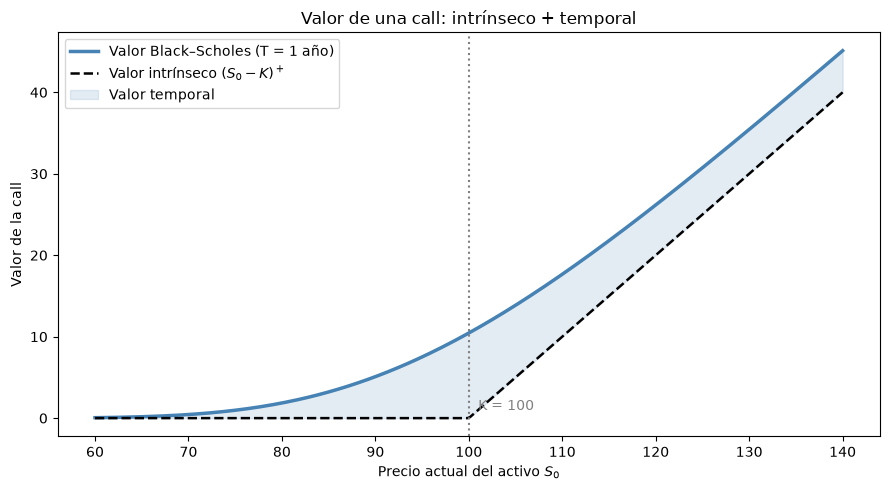

In [6]:
S0_rango = np.linspace(60, 140, 300)
valor_bs   = np.array([precio_bs(s, K, r, sigma, T, 'call') for s in S0_rango])
intrinseco = np.maximum(S0_rango - K, 0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(S0_rango, valor_bs,   color='steelblue', linewidth=2.5, label='Valor Black–Scholes (T = 1 año)')
ax.plot(S0_rango, intrinseco, color='black', linestyle='--', linewidth=1.8, label='Valor intrínseco $(S_0-K)^+$')
ax.fill_between(S0_rango, intrinseco, valor_bs, color='steelblue', alpha=0.15, label='Valor temporal')
ax.axvline(K, color='gray', linestyle=':'); ax.annotate('K = 100', (K + 1, 1), color='gray')
ax.set_xlabel('Precio actual del activo $S_0$'); ax.set_ylabel('Valor de la call')
ax.set_title('Valor de una call: intrínseco + temporal')
ax.legend(); plt.tight_layout(); plt.show()

---

# Sección 4 — Monte Carlo frente a Black–Scholes

## 4.1 Validación cruzada

El momento de la verdad: ¿coincide el precio Monte Carlo con la fórmula cerrada? El criterio riguroso no es "que se parezcan", sino medir la discrepancia en unidades de su propio error estándar:

$$
z = \frac{\lvert \hat V_{\text{MC}} - V_{\text{BS}} \rvert}{\mathrm{SE}}
$$

Si el Monte Carlo es correcto, $z$ debe ser del orden de 1: la diferencia con Black–Scholes es del tamaño del ruido estadístico esperado, no mayor. Un $z < 1.96$ equivale a que Black–Scholes cae dentro del intervalo de confianza del 95%.

Una advertencia estadística importante para leer la tabla con honestidad: un IC del 95% **está diseñado para fallar 1 de cada 20 veces**. Con 6 escenarios, la probabilidad de que *alguno* se salga del IC ronda el 26% ($1 - 0.95^6$) — así que ver ocasionalmente un $z$ ligeramente por encima de 1.96 no es un fallo del método, sino exactamente el comportamiento que predice la teoría. Lo que sería sospechoso es un $z$ grande (3, 4, 5...), señal de un sesgo sistemático. Probamos call y put, dentro (ITM), en (ATM) y fuera del dinero (OTM):

In [7]:
escenarios = [
    ("Call ATM",  100, 'call'), ("Call ITM",   90, 'call'), ("Call OTM",  110, 'call'),
    ("Put  ATM",  100, 'put'),  ("Put  ITM",  110, 'put'),  ("Put  OTM",   90, 'put'),
]
N = 2_000_000

print(f"{'Escenario':<10} {'K':>4}  {'MC':>9}  {'SE':>8}  {'Black-Scholes':>13}  {'z':>6}")
print("-" * 60)
for nombre, strike, tipo in escenarios:
    mc, se = precio_mc(S0, strike, r, sigma, T, N, rng, tipo)
    bs = precio_bs(S0, strike, r, sigma, T, tipo)
    z  = abs(mc - bs) / se
    print(f"{nombre:<10} {strike:>4}  {mc:>9.4f}  {se:>8.4f}  {bs:>13.4f}  {z:>6.2f}")

print("\nDiscrepancia en errores estándar (z). Se espera z ~ 1; z < 1.96 ⟺ BS dentro del IC 95%.")

Escenario     K         MC        SE  Black-Scholes       z
------------------------------------------------------------
Call ATM    100    10.4330    0.0104        10.4506    1.69
Call ITM     90    16.7064    0.0123        16.6994    0.56


Call OTM    110     6.0522    0.0082         6.0401    1.47
Put  ATM    100     5.5604    0.0061         5.5735    2.15
Put  ITM    110    10.6733    0.0085        10.6753    0.24


Put  OTM     90     2.3082    0.0038         2.3101    0.50

Discrepancia en errores estándar (z). Se espera z ~ 1; z < 1.96 ⟺ BS dentro del IC 95%.


## 4.2 El error se reduce como $1/\sqrt{N}$ — y cómo acelerarlo

Ya vimos la convergencia en §2.3. Cerramos cuantificando el coste: la siguiente tabla muestra el error estándar (el semiancho del IC) para $N$ creciente. Cada factor de 100 en $N$ recorta el error en un factor de 10 — el precio a pagar por el método más general que existe para valorar derivados.

In [8]:
print(f"{'N':>12}  {'precio MC':>10}  {'SE':>9}  {'semiancho IC 95%':>16}")
print("-" * 54)
for N in [10_000, 100_000, 1_000_000, 10_000_000]:
    mc, se = precio_mc(S0, K, r, sigma, T, N, rng, 'call')
    print(f"{N:>12,}  {mc:>10.4f}  {se:>9.4f}  {1.96*se:>16.4f}")
print(f"\nReferencia exacta Black–Scholes: {precio_bs(S0, K, r, sigma, T, 'call'):.4f}")

           N   precio MC         SE  semiancho IC 95%
------------------------------------------------------
      10,000     10.6257     0.1493            0.2926
     100,000     10.3795     0.0463            0.0908
   1,000,000     10.4425     0.0147            0.0289


  10,000,000     10.4516     0.0047            0.0091

Referencia exacta Black–Scholes: 10.4506


## 4.3 Cierre del módulo

**Qué hemos construido.** Hemos valorado una opción europea por dos caminos independientes —Monte Carlo y la fórmula cerrada de Black–Scholes— y hemos comprobado que **coinciden dentro del error estadístico** en todos los escenarios. El Monte Carlo, un método puramente numérico y genérico, reproduce una fórmula analítica célebre: esa es la validación de que el andamiaje conceptual (medida neutral al riesgo, descuento, promedio) es correcto.

**La idea que vertebra el módulo.** La valoración neutral al riesgo (§1.3) resuelve el problema que dejamos abierto en el Módulo 2: el drift real $\mu$ es inestimable, pero **no hace falta** para valorar derivados, porque bajo la medida $\mathbb{Q}$ el drift es la tasa libre de riesgo $r$. El precio de un derivado no depende de las expectativas de rentabilidad del activo, solo de su volatilidad y del tipo sin riesgo.

**Análisis honesto — qué hereda y qué añade.**

1. **Hereda las limitaciones del GBM** (Módulo 2, §4): al suponer volatilidad constante y rentabilidades normales, Black–Scholes ignora las colas gruesas y el agrupamiento de volatilidad. En la práctica esto se manifiesta como la *sonrisa de volatilidad* (la $\sigma$ implícita en los precios de mercado no es constante en el strike), síntoma de que el modelo es una aproximación.
2. **¿Para qué Monte Carlo, si existe la fórmula?** Para la call europea, Black–Scholes es superior — instantáneo y exacto. La potencia de Monte Carlo aparece justo donde **no hay fórmula cerrada**: opciones dependientes de la trayectoria (asiáticas, barrera), múltiples subyacentes, o modelos más ricos que el GBM. Este módulo es el banco de pruebas donde validamos el método contra un caso con solución conocida, para poder confiar en él cuando no la haya.

**Puente al Módulo 4.** Hemos preguntado *cuánto vale* un contrato. La siguiente pregunta es la del riesgo: *¿cuánto podría perder* una cartera en un horizonte dado? En el Módulo 4 usaremos el mismo motor de simulación para estimar el **Valor en Riesgo (VaR)** por Monte Carlo — la primera medida de riesgo del proyecto.

## Referencias

- Black, F. & Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy, 81(3).
- Hull, J. C. (2018). *Options, Futures and Other Derivatives*, caps. 13–15.
- Shreve, S. E. (2004). *Stochastic Calculus for Finance II*, caps. 4–5.
- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, caps. 1 y 3.